# <center>Segmentación de clientes de un centro comercial</center>

### Objetivo:
- Clasificar o agrupar a los clientes del centro comercial basándose en características numéricas y categóricas.
- Se trata de un problema de **aprendizaje no supervisado**.

### <center>Atributos del conjunto de datos</center>

- **CustomerID** : Identificador único asignado al cliente
- **Gender** : Género del cliente
- **Age** : Edad del cliente
- **Annual Income (k$)** : Ingresos anuales del cliente
- **Spending Score (1-1000)** : Puntuación asignada por el centro comercial basada en el comportamiento del cliente y sus hábitos de gasto

### Contenido del notebook:
- Información del conjunto de datos
- Análisis exploratorio de datos (EDA)
- Resumen del EDA
- Ingeniería de características
- Modelado
- Conclusión

### Lo que aprenderás:
- Técnicas de visualización de datos.
- Información sobre el algoritmo de agrupamiento K-Means.
- Pruebas estadísticas para la selección de hiperparámetros.
- Diferencias en el rendimiento del modelo al entrenarlo con el conjunto de datos original frente al normalizado.

### Trabajos recientes:

- [Clasificación binaria](https://www.kaggle.com/competitions/titanic/discussion/352223) **: Describe el enfoque necesario para abordar problemas de clasificación binaria mediante notebooks que presentan trabajos realizados con conjuntos de datos, incluyendo explicaciones del código claras y fáciles de entender.**
- [Análisis de series temporales](https://www.kaggle.com/competitions/store-sales-time-series-forecasting/discussion/352205) **: Describe los fundamentos del análisis de series temporales mediante notebooks que presentan trabajos realizados con conjuntos de datos, incluyendo explicaciones del código claras y fáciles de entender.**

### ¡Empecemos!

# <center>Dataset Information</center>

### Import the Necessary Libraries :

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

In [3]:
data = pd.read_csv('Mall_Customers.csv')
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Información del conjunto de datos :

In [4]:
data.shape

(200, 5)

In [5]:
data.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


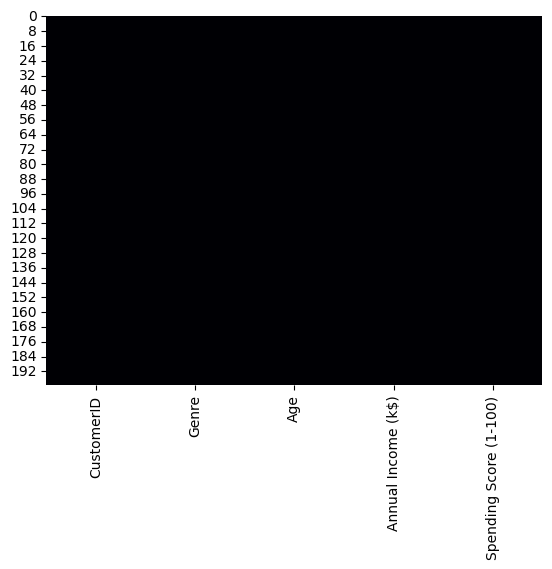

In [7]:
sns.heatmap(data.isnull(),cmap = 'magma',cbar = False);

- ¡No hay valores nulos presentes en los datos!

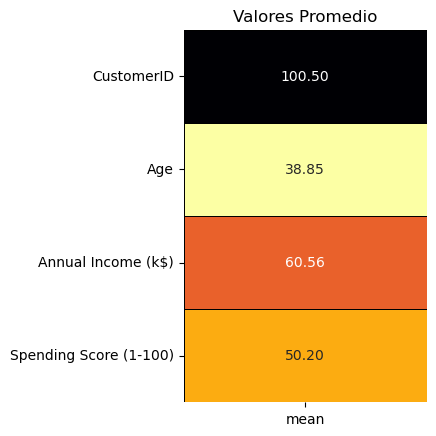

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

plt.subplot(1, 1, 1)
sns.heatmap(
    data.describe().T[['mean']],
    cmap='inferno_r',
    annot=True,
    fmt='.2f',
    linecolor='black',
    linewidths=0.4,
    cbar=False
)

plt.title('Valores Promedio')

fig.tight_layout(pad=3)

- El promedio de edad del cliente en el conjunto de datos está a finales de los 30, es decir **38.85**.
- El promedio de **Ingreso Anual (k$)** de los clientes es **60.56**, es decir, apenas por debajo del ingreso mediano de 2018 de un ciudadano estadounidense, 63k$.
- El promedio de **Spending Score (1-100)** de los clientes del centro comercial está en el centro con **50.20**.

# <center>Análisis Exploratorio de Datos</center>

### División de características en Numéricas y Categóricas :

In [10]:
col = list(data.columns)
categorical_features = []
numerical_features = []
for i in col:
    if len(data[i].unique()) > 6:
        numerical_features.append(i)
    else:
        categorical_features.append(i)

print('Categorical Features :',*categorical_features)
print('Numerical Features :',*numerical_features)

Categorical Features : Genre
Numerical Features : CustomerID Age Annual Income (k$) Spending Score (1-100)


- Aquí, las características se definen como categóricas si el atributo tiene menos de 6 elementos únicos; de lo contrario, es una característica numérica.
- Un enfoque típico para esta división también puede basarse en los tipos de datos de los elementos del atributo respectivo.

**Ej :** tipo de datos = entero, atributo = característica numérica ; tipo de datos = cadena, atributo = característica categórica

- Para este conjunto de datos, como el número de características es pequeño, también podemos verificar el conjunto de datos manualmente.

In [14]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df1 = data.copy(deep = True)

df1['Genre'] = le.fit_transform(df1['Genre'])

print('Label Encoder Transformation')
print(df1['Genre'].unique(),' = ',le.inverse_transform(df1['Genre'].unique()))

Label Encoder Transformation
[1 0]  =  ['Male' 'Female']


In [13]:
print(data.columns.tolist())

['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


- Creando una copia profunda del conjunto de datos original y codificando con etiquetas los datos de texto de **Gender**.
- Las modificaciones en el conjunto de datos original no se reflejarán en esta copia profunda.
- Por lo tanto, usamos esta copia profunda del conjunto de datos que tiene **Gender** convertido en valores numéricos para fines de visualización y modelado.

### Distribución de las características categóricas y numéricas :

C:\Users\derek\AppData\Local\Temp\ipykernel_10280\2039315377.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[categorical_features[i]],kde_kws = {'bw' : 1});
d:\Anaconda\Lib\site-packages\seaborn\distributions.py:2496: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=1`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)
C:\Users\derek\AppData\Local\Temp\ipykernel_10280\2039315377.py:11: UserWarning: 

`distplot` is a deprecated function and will be remov

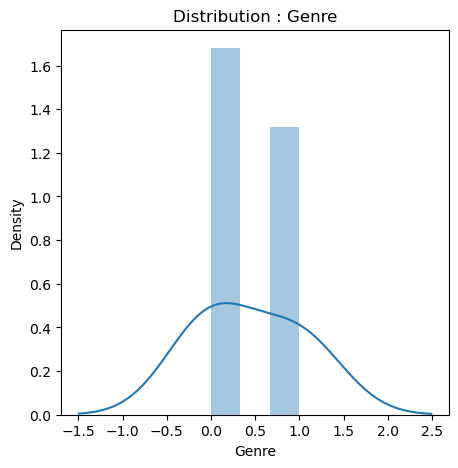

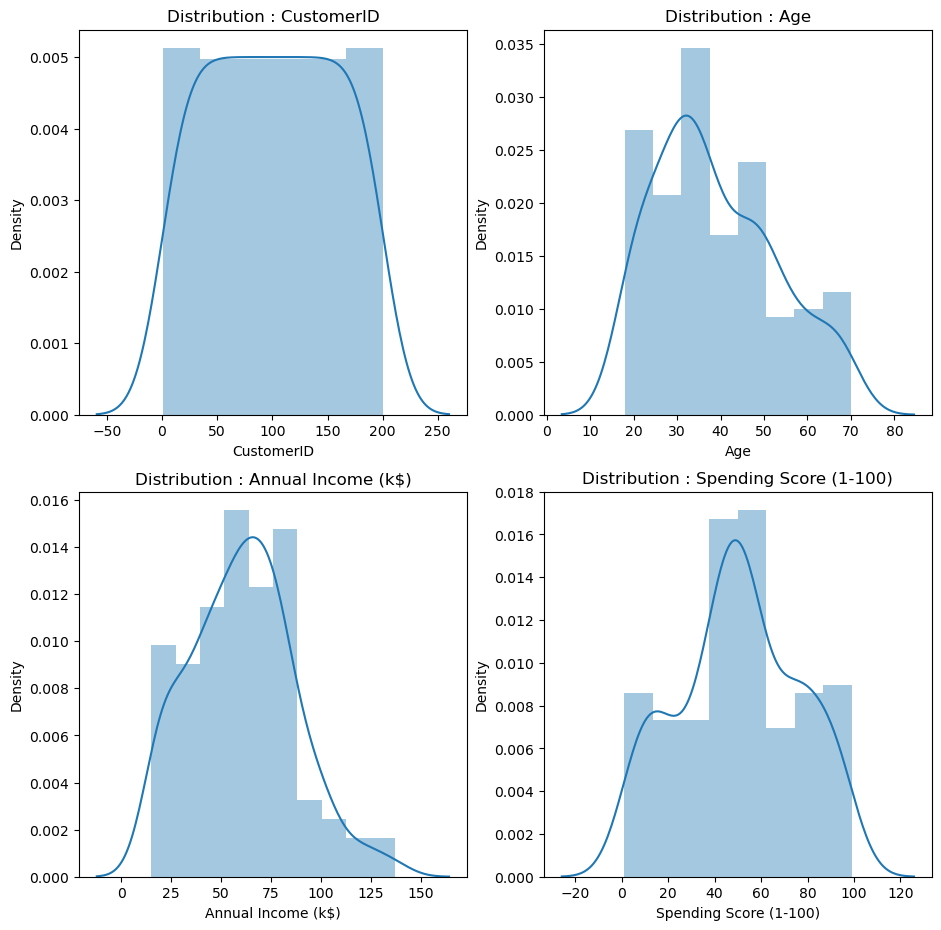

In [15]:
fig, ax = plt.subplots(nrows = 1,ncols = 1,figsize = (5,5))
for i in range(len(categorical_features)):
    plt.subplot(1,1,i+1)
    sns.distplot(df1[categorical_features[i]],kde_kws = {'bw' : 1});
    title = 'Distribution : ' + categorical_features[i]
    plt.title(title)
    
fig, ax = plt.subplots(nrows = 2,ncols = 2,figsize = (11,11))
for i in range(len(numerical_features)):
    plt.subplot(2,2,i+1)
    sns.distplot(data[numerical_features[i]],)
    title = 'Distribution : ' + numerical_features[i]
    plt.title(title)
plt.show()

- **Gender**, la única característica categórica, muestra una distribución **normal**.
- La distribución de **Age** y **Annual Income (k$)** está **sesgada positivamente o hacia la derecha**.
- La distribución de **Spending Score (1-100)** es similar al patrón de **Head and Shoulders** observado en gráficos de acciones.
- Muestra el precio de una acción subiendo hasta un pico y luego descendiendo de nuevo al nivel anterior. Algo similar se observa con los **2 hombros** que se forman alrededor de los valores **20 y 80**, siendo la **cabeza** centrada entre **40 - 60**.
- Eliminaremos la característica **CustomerID** ya que es solo un número asignado a un cliente.

In [16]:
numerical_features.remove('CustomerID')

### Características Categóricas :

C:\Users\derek\AppData\Local\Temp\ipykernel_10280\3064336420.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Mujer', 'Hombre'])


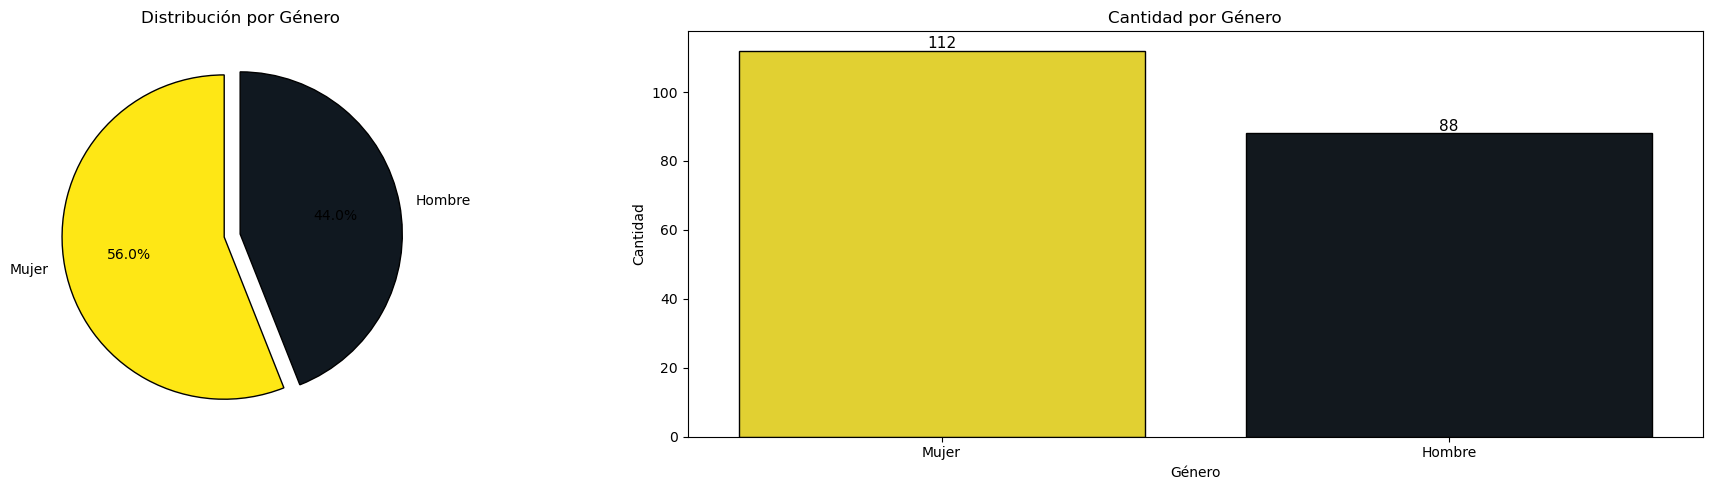

In [19]:
l = list(data['Genre'].value_counts())

circle = [
    l[0] / sum(l) * 100,
    l[1] / sum(l) * 100
]

colors = ['#FEE715', '#101820']

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))

# Gráfica de pastel
plt.subplot(1, 2, 1)

plt.pie(
    circle,
    labels=['Mujer', 'Hombre'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.1, 0),
    colors=colors,
    wedgeprops={
        'edgecolor': 'black',
        'linewidth': 1,
        'antialiased': True
    }
)

plt.title('Distribución por Género')


# Gráfica de barras
plt.subplot(1, 2, 2)

ax = sns.countplot(
    x='Genre',
    data=df1,
    palette=colors,
    edgecolor='black',
    hue='Genre',
    legend=False
)

for rect in ax.patches:
    ax.text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height() + 0.75,
        int(rect.get_height()),
        horizontalalignment='center',
        fontsize=11
    )

plt.title('Cantidad por Género')
plt.xlabel('Género')
plt.ylabel('Cantidad')

ax.set_xticklabels(['Mujer', 'Hombre'])

plt.tight_layout()
plt.show()

- Para el conjunto de datos anterior, las clientes **mujeres** superan por poco a los clientes **hombres**.

### Características Numéricas vs Características Categóricas :

C:\Users\derek\AppData\Local\Temp\ipykernel_10280\3972980304.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Mujer', 'Hombre'])
C:\Users\derek\AppData\Local\Temp\ipykernel_10280\3972980304.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Mujer', 'Hombre'])
C:\Users\derek\AppData\Local\Temp\ipykernel_10280\3972980304.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Mujer', 'Hombre'])
C:\Users\derek\AppData\Local\Temp\ipykernel_10280\3972980304.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Mujer', 'Hombre'])
C:\Users\derek\AppData\Local\Temp\ipykernel_1028

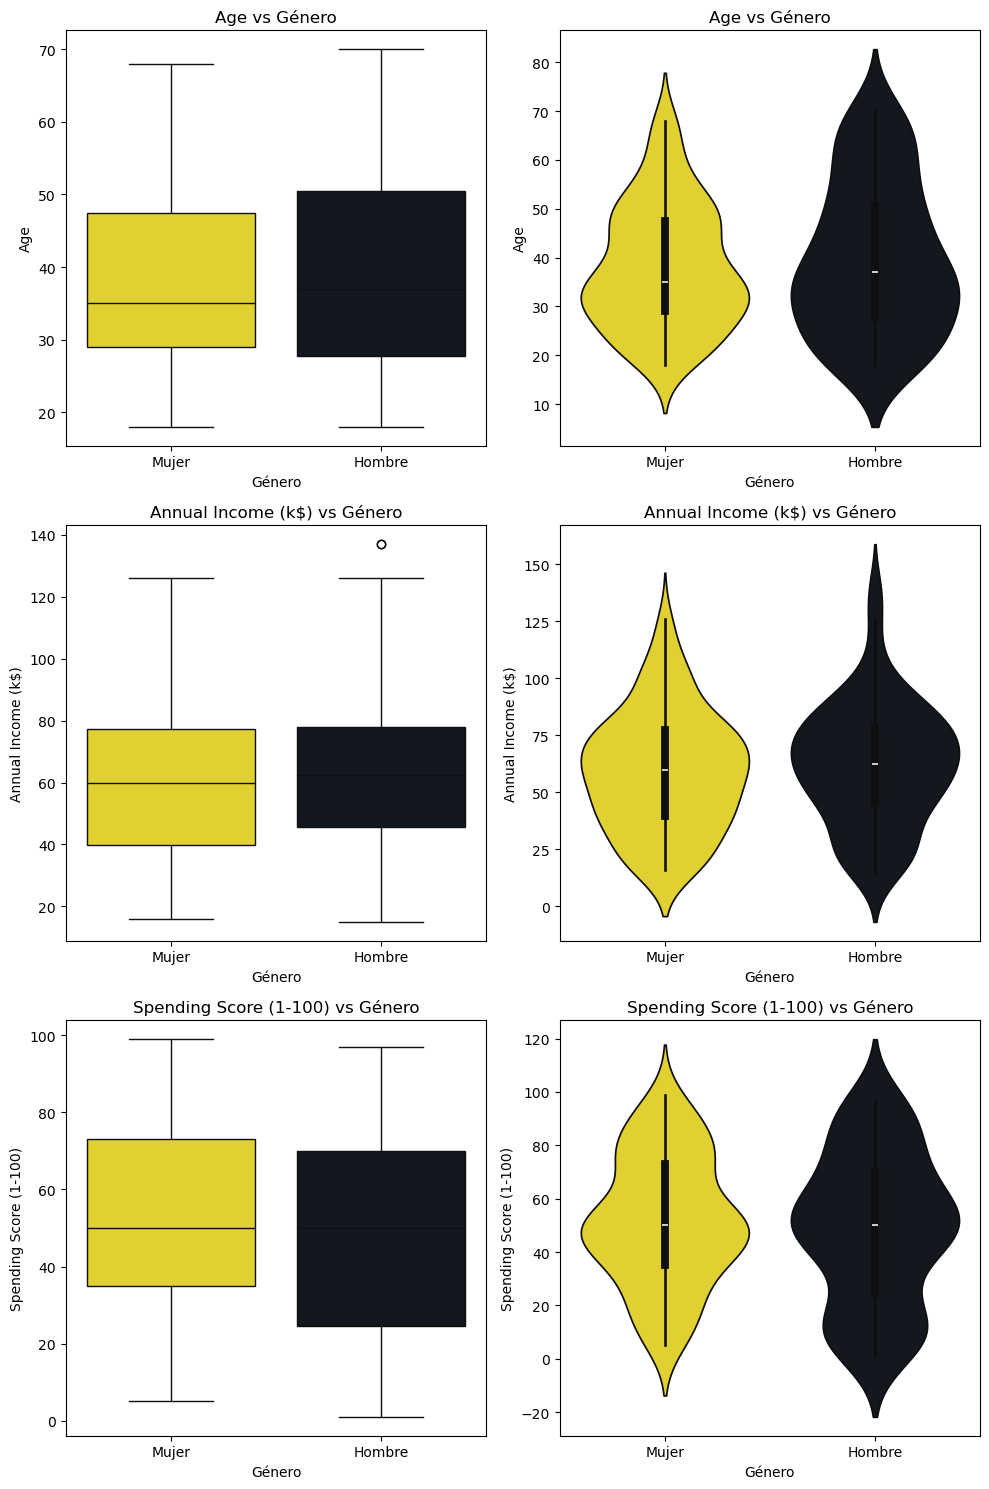

In [21]:
fig = plt.subplots(nrows=3, ncols=2, figsize=(10, 15))

for i in range(len(numerical_features)):

    # Gráfica Boxplot
    plt.subplot(3, 2, (i * 2) + 1)

    ax = sns.boxplot(
        x='Genre',
        y=numerical_features[i],
        data=df1,
        hue='Genre',
        palette=colors,
        legend=False
    )

    ax.set_xticklabels(['Mujer', 'Hombre'])

    title = numerical_features[i] + ' vs Género'
    plt.title(title)
    plt.xlabel('Género')
    plt.ylabel(numerical_features[i])


    # Gráfica Violinplot
    plt.subplot(3, 2, (i * 2) + 2)

    ax = sns.violinplot(
        x='Genre',
        y=numerical_features[i],
        data=df1,
        hue='Genre',
        palette=colors,
        legend=False
    )

    ax.set_xticklabels(['Mujer', 'Hombre'])

    title = numerical_features[i] + ' vs Género'
    plt.title(title)
    plt.xlabel('Género')
    plt.ylabel(numerical_features[i])

plt.tight_layout()
plt.show()

- El rango de **Age** de las clientes **mujeres** es de **30 a poco menos de 50**, mientras que en los clientes **hombres** el rango de **Age** es de **poco menos de 30 a 50**.
- Para ambos **géneros**, se observa un aumento en la edad de **30 - 35**. La mediana de **Age** de los clientes **hombres** es ligeramente mayor que la de las **mujeres**.
- Para **Annual Income (k$)**, el ingreso de las clientes **mujeres** comienza en **40k**, mientras que el de los clientes **hombres** está por encima de este valor.
- La mediana de **Annual Income (k$)** para ambos **géneros** está cerca de **60k**. El **Annual Income (k$)** de los clientes **hombres** se reduce muy bruscamente en el extremo superior, con algunos valores atípicos en comparación con los clientes **mujeres**.
- La mediana de **Spending Score (1-100)** de ambos **géneros** es la misma, a pesar de tener diferentes puntos de partida de **poco menos de 40** y **poco más de 20** para los clientes **mujeres** y **hombres**, respectivamente.
- Ambos **géneros** muestran un fuerte aumento en el valor mediano, especialmente los clientes **mujeres**. Sin embargo, los clientes **hombres** también muestran un aumento pequeño pero significativo en el rango de **0 - 20**.